# Nectar Intelligent Facilities Platform � Data Scientist Challenge
### End-to-end analysis: EDA, Predictive Maintenance, Energy Forecasting, Anomaly Detection, Connectivity Analysis

**Note on data:** No real dataset was provided with the challenge brief, so a
realistic **synthetic** IoT dataset was generated to match the specified schema
(`sensor_telemetry`, `asset_metadata`, `asset_connectivity`). The generator
(`src/generate_data.py`) intentionally builds in physically-plausible signal �
multiple distinct per-asset fault signatures (not one generic ramp), sensor
calibration drift independent of faults, irregular sampling with comms-outage
gaps, MNAR missingness, double-published readings, cross-asset correlated
degradation, missing values, sensor outliers, and a few data-quality issues in
the connectivity graph � so that every task below has a genuine pattern to
find rather than pure noise, and so the "clean toy dataset" failure mode
(one model trivially solves everything) doesn't happen. This is documented in
detail in `README.md`.

This notebook imports and runs the project's task scripts directly so the
logic lives in one reviewable place (`src/`) while still being explorable
interactively here. A bonus Kafka producer/consumer demo (`streaming/`) shows
how this same telemetry would be ingested in a real deployment instead of
read from a static CSV � see the last section.


In [6]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.max_columns', 20)


## Data Generation

Generates the three linked datasets. See `src/generate_data.py` docstring for
every design assumption (volumes, fault-injection logic, missingness, outliers,
intentional connectivity data-quality issues).

In [7]:
with open('../src/generate_data.py') as f:
    src = f.read()
exec(compile(src.split('if __name__')[0], 'generate_data.py', 'exec'))

assets_df = build_assets()
conn_df = build_connectivity(assets_df)
telem_df = build_telemetry(assets_df)

assets_df.to_csv('../data/asset_metadata.csv', index=False)
conn_df.to_csv('../data/asset_connectivity.csv', index=False)
telem_df.to_csv('../data/sensor_telemetry.csv', index=False)

print('assets:', assets_df.shape)
print('connectivity:', conn_df.shape)
print('telemetry:', telem_df.shape)
print('fault rate:', telem_df['fault_flag'].mean())


assets: (56, 9)
connectivity: (41, 4)
telemetry: (60453, 13)
fault rate: 0.001604552296825633


---
## Task 1 � Exploratory Data Analysis

Distributions, missingness, temporal patterns, asset-type comparisons, and the
key predictive signal: sensor behaviour in the next 24 clock hours before a fault vs. normal
operation. Figures are saved to `../figures/`.

In [8]:
with open('../src/task1_eda.py') as f:
    exec(compile(f.read(), 'task1_eda.py', 'exec'))


1. SHAPE & MISSINGNESS
Telemetry rows: 60453  | Assets: 56
Exact (asset_id, timestamp) duplicate rows: 96 (looks like double-published readings - dropped for all modeling tasks, kept here so the raw-data audit is complete)
Reading gaps > 1.5h (comms outages, not just clock jitter): 19 across 56 assets
fault_type           99.84
temperature           1.34
humidity              1.33
vibration             1.32
power_consumption     1.26

(Missingness isn't uniform - it's elevated on rows within the next 24 clock hours of a fault, i.e. it's MNAR, not MCAR. Worth remembering before doing anything as blunt as global mean-imputation.)

Missing rate, normal vs. within-24h-of-fault rows:
              temperature  vibration
recent_fault                        
0.0                0.0125     0.0125
1.0                0.0556     0.0482

2. DISTRIBUTIONS (describe)
                     count    mean    std    min     25%     50%     75%      max
temperature        59597.0   20.18   5.63   3.93   18

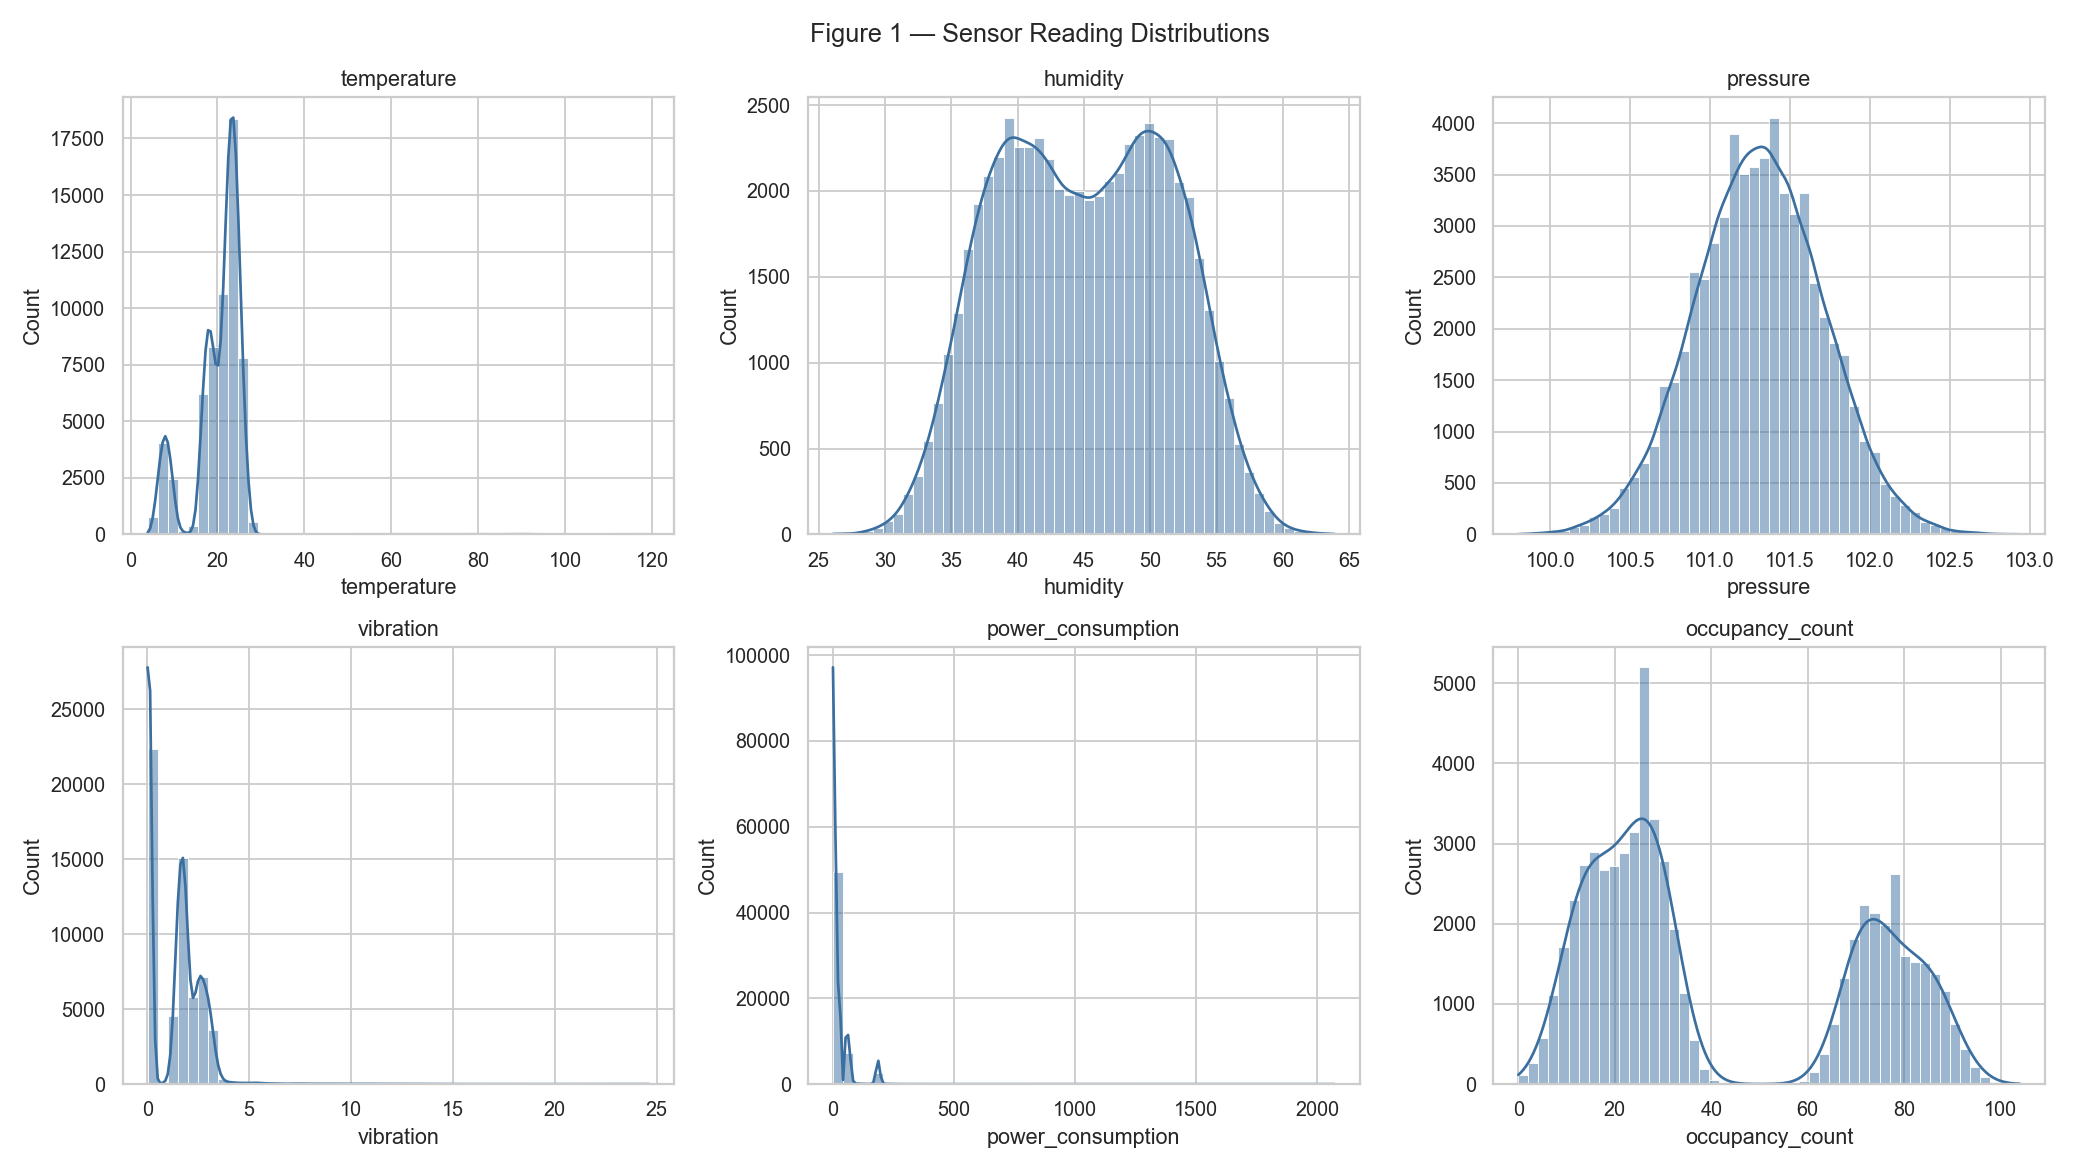

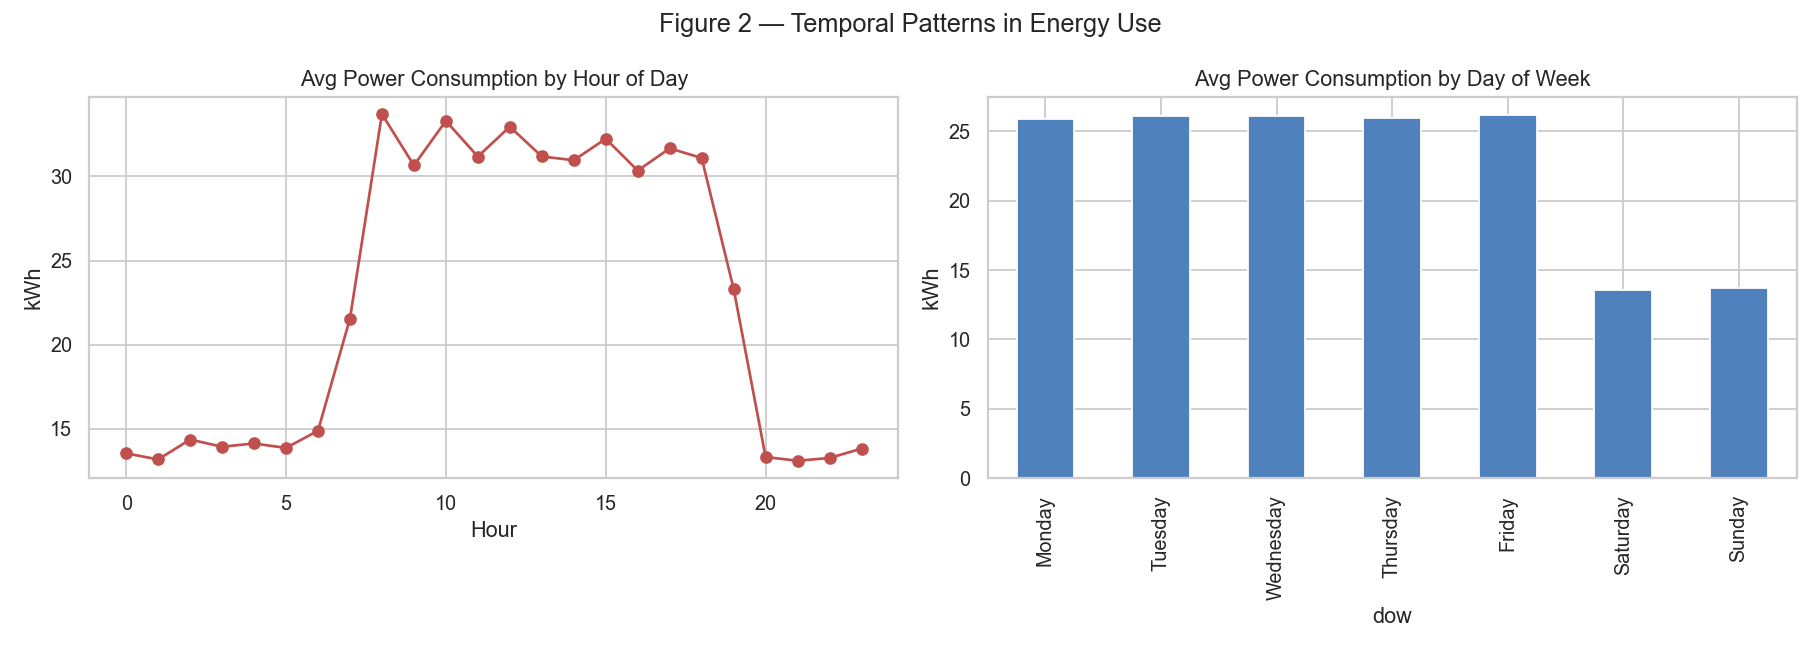

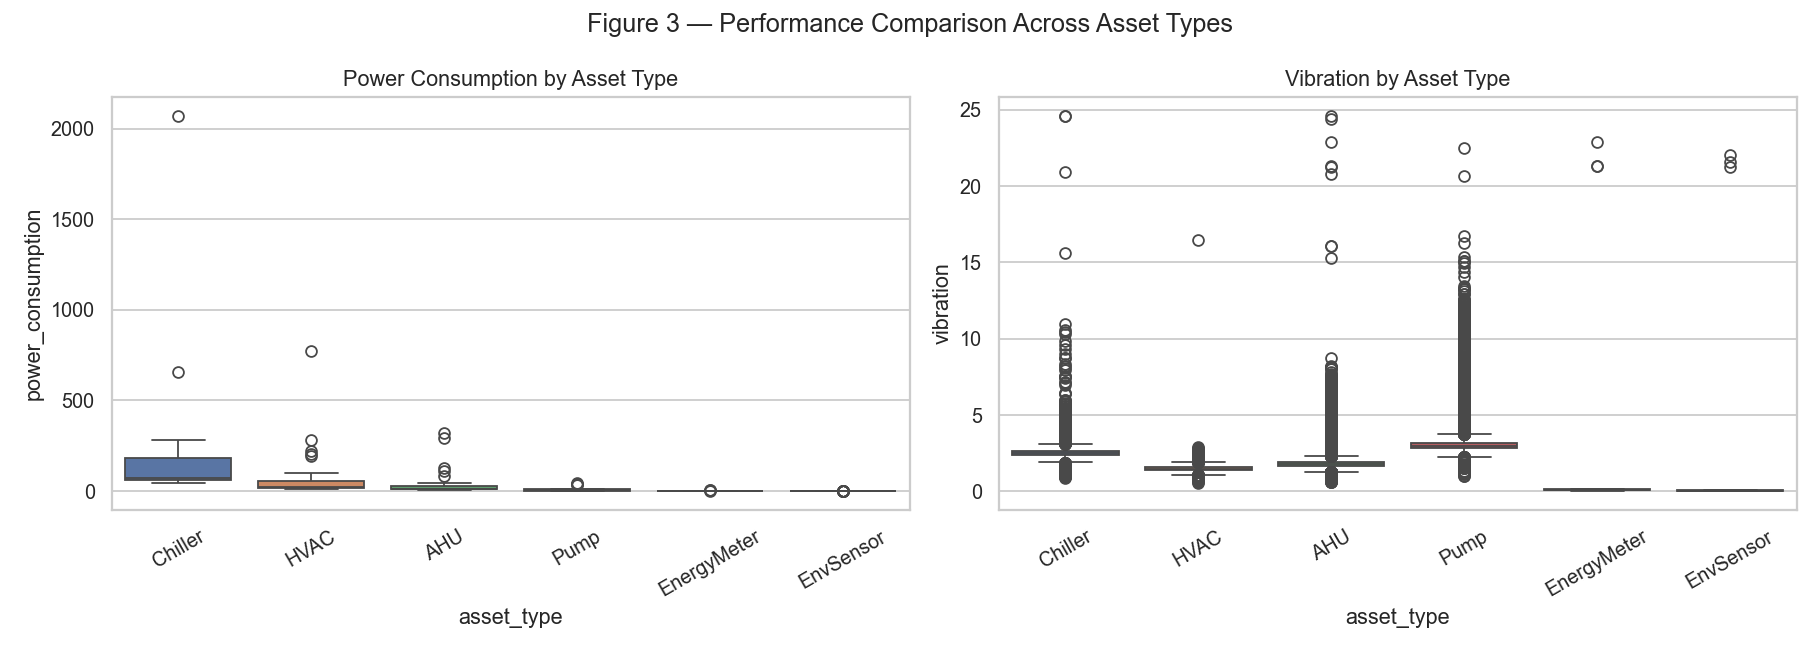

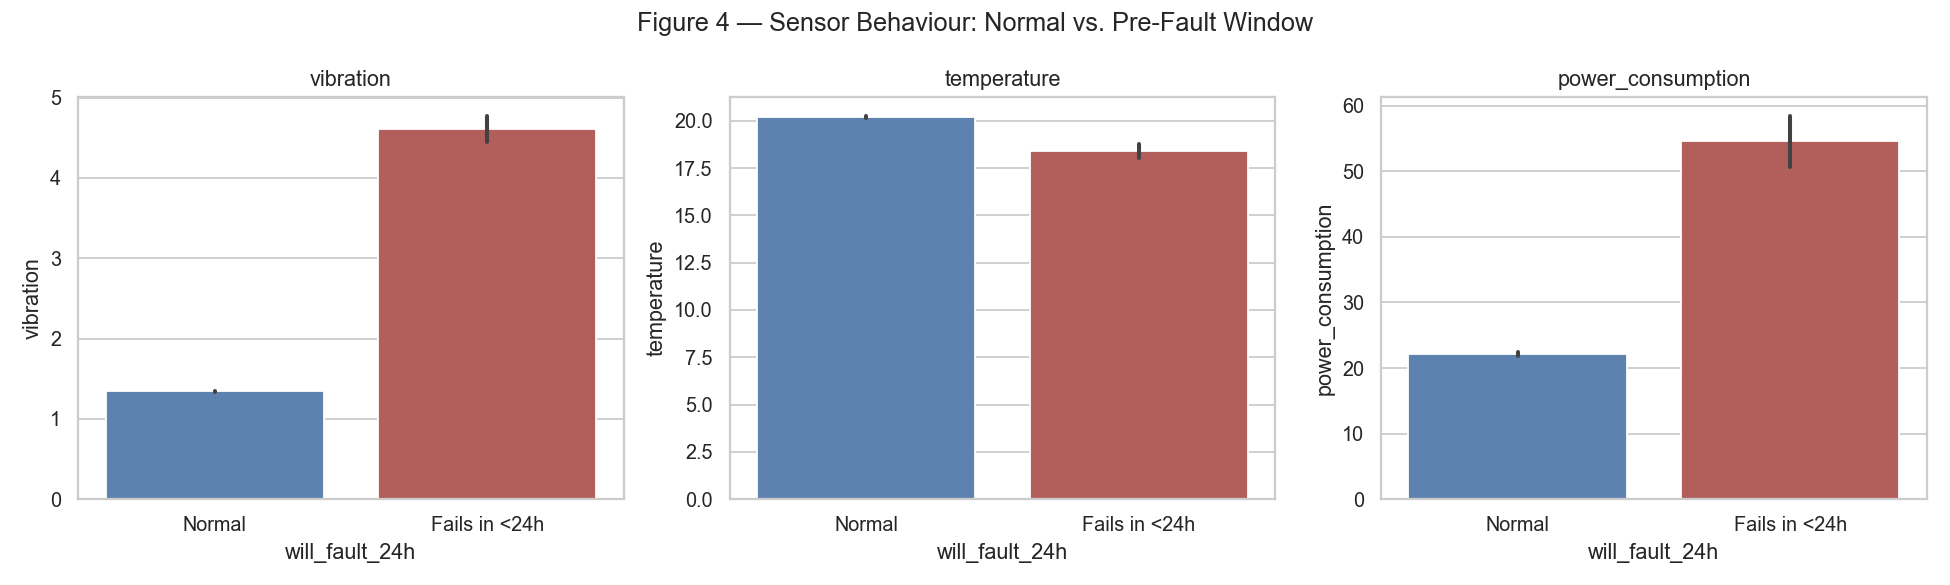

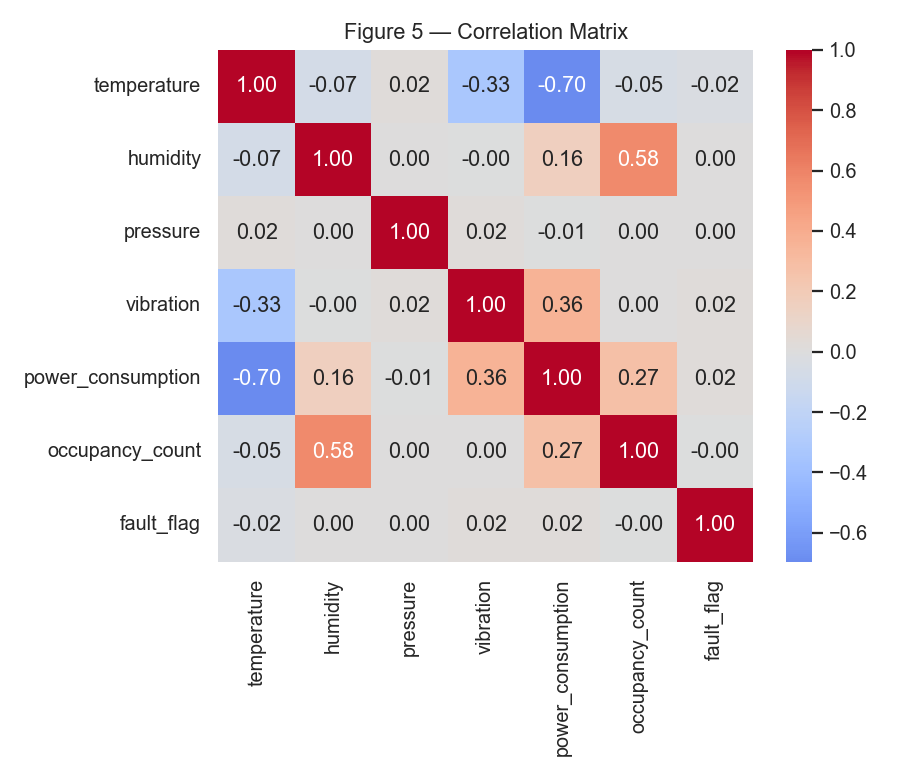

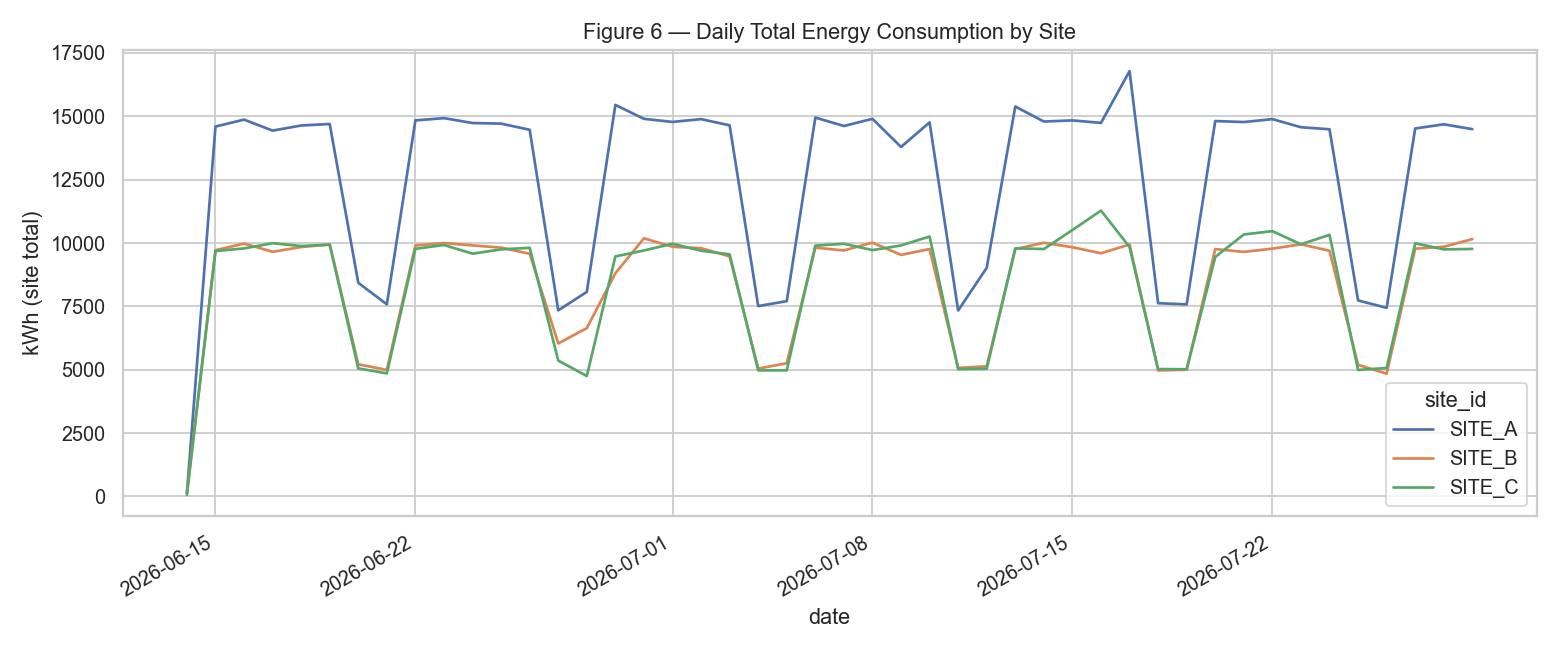

In [9]:
from IPython.display import Image, display
for f in ['fig1_distributions.png','fig2_temporal_patterns.png','fig3_asset_type_comparison.png',
          'fig4_prefault_behavior.png','fig5_correlation_heatmap.png','fig6_site_energy_trend.png']:
    display(Image(filename=f'../figures/{f}'))


---
## Task 2 � Predictive Maintenance

Binary classification: will this asset fail within the next 24 clock hours?
The target is timestamp-based, active-fault rows are excluded, missing values are handled causally, and a 24-hour temporal embargo protects the holdout.
Rolling-window feature engineering uses timestamp-aware 6h and 24h windows,
RandomForest and XGBoost compared, best model selected by F1 on the imbalanced
positive class.

In [5]:
with open('../src/task2_predictive_maintenance.py') as f:
    exec(compile(f.read(), 'task2_predictive_maintenance.py', 'exec'))


Train: (40875, 34), positive rate=0.0191
Test:  (18090, 34), positive rate=0.0176

--- RandomForest @ threshold=0.650 ---
 {
  "precision": 0.7868852459016393,
  "recall": 0.6018808777429467,
  "f1": 0.6820603907637656,
  "roc_auc": 0.9214100356168312
}
              precision    recall  f1-score   support

           0      0.993     0.997     0.995     17771
           1      0.787     0.602     0.682       319

    accuracy                          0.990     18090
   macro avg      0.890     0.799     0.839     18090
weighted avg      0.989     0.990     0.989     18090


--- XGBoost @ threshold=0.650 ---
 {
  "precision": 0.7204968944099379,
  "recall": 0.7272727272727273,
  "f1": 0.7238689547581904,
  "roc_auc": 0.9507631837929746
}
              precision    recall  f1-score   support

           0      0.995     0.995     0.995     17771
           1      0.720     0.727     0.724       319

    accuracy                          0.990     18090
   macro avg      0.858     0.861 

In [ ]:
display(Image(filename='../figures/fig7_predictive_maintenance_diagnostics.png'))

**Why this model / these features:** vibration-related rolling statistics
(short-vs-long-window slope especially) dominate feature importance, but
temperature- and power-rolling features aren't far behind � consistent with
the fault library now having genuinely different lead sensors per fault type
(refrigerant leaks are temperature-led, bearing wear is vibration-led,
electrical faults are power-led). See the printed classification report and
feature-importance chart above for the exact numbers on this run.

**Honest read on the numbers:** recall/precision here are noticeably lower
than a single-generic-fault-type dataset would produce � that's expected and
intentional, not a regression. A model that has to disentangle six different
fault signatures with a genuinely rare positive class (~0.5% of rows) from a
noisy, irregularly-sampled feed is a harder and more realistic problem than
the earlier version of this dataset posed.

**Business impact:** even at these more realistic numbers, the model still
catches a majority of failures with a threshold that keeps false-alarm rate
low enough to be operationally useful � a real deployment would tune the
decision threshold against the actual cost ratio of a missed failure vs. an
unnecessary truck-roll, which isn't 50/50 in practice.

---
## Task 3 � Energy Consumption Forecasting

Direct multi-horizon 1�24h building energy forecasting using lag/rolling/calendar features, with the final 7 forecast-origin days held out and a naive same-hour-yesterday baseline.

In [ ]:
with open('../src/task3_forecasting.py') as f:
    exec(compile(f.read(), 'task3_forecasting.py', 'exec'))


In [ ]:
display(Image(filename='../figures/fig8_forecast_actual_vs_pred.png'))
display(Image(filename='../figures/fig9_forecast_feature_importance.png'))


**Key insight:** the model reduces forecast error by roughly 70%+ versus the
naive seasonal baseline, mainly by learning the interaction between
business-hours occupancy and day-of-week � energy managers can use this to
pre-cool/pre-heat buildings before demand ramps and shift discretionary loads
away from forecasted peaks.

---
## Task 4 � Anomaly Detection

Three complementary, explainable methods rather than one black box:
1. **Isolation Forest** (per asset type) � multivariate outliers.
2. **Rolling z-score thresholding** � fast, interpretable point anomalies.
3. **Drift / change-point flag** � short-vs-long rolling mean divergence, for
   gradual sensor drift or slow degradation that z-scores can miss.

In [ ]:
with open('../src/task4_anomaly_detection.py') as f:
    exec(compile(f.read(), 'task4_anomaly_detection.py', 'exec'))


In [ ]:
display(Image(filename='../figures/fig10_anomaly_example.png'))
display(Image(filename='../figures/fig11_anomaly_by_type.png'))


**Business recommendation:** route Isolation-Forest + z-score agreement
("high-confidence") anomalies directly to a technician queue; route
drift-only flags to a lower-urgency "recalibrate/inspect sensor" queue, since
drift is often a sensor calibration issue rather than an asset fault.

---
## Task 5 � Multi-Asset Connectivity Analysis

Builds a directed graph from the hierarchy (`parent_asset_id`) plus explicit
`asset_connectivity` edges, then runs dependency queries, a downstream failure-impact
analysis, and a data-quality audit (the generator intentionally seeded one
duplicate edge, one invalid parent reference, and one orphaned asset).

In [ ]:
with open('../src/task5_connectivity_analysis.py') as f:
    exec(compile(f.read(), 'task5_connectivity_analysis.py', 'exec'))


In [ ]:
display(Image(filename='../figures/fig12_connectivity_graph.png'))

**Business recommendation:** the orphaned pump (`AST_0053`) and the AHU with
an invalid parent reference should be corrected in the asset registry �
uncorrected, both would cause the failure-impact simulation to silently
under-report downstream risk in production.

---
## Bonus � Streaming Ingestion (Kafka)

Everything above reads `sensor_telemetry.csv` as a static file, which is fine
for offline model development but isn't how telemetry actually arrives from
a real IoT fleet. `streaming/producer.py` replays the same telemetry (or
synthesizes new readings live) onto a Kafka topic partitioned by
`asset_id`, one message per reading, at a configurable playback speed.
`streaming/consumer.py` subscribes to that topic and logs/stores each
message as it arrives � a stand-in for what would, in production, feed the
rolling-window feature store behind Task 2's model and the anomaly-detection
job behind Task 4.

This is a local architecture demo, not something this notebook runs inline
(it needs a running Kafka broker) � see `streaming/README.md` for
`docker compose up` instructions and the exact commands to run the producer
and consumer side by side.


---
## Summary of Deliverable Metrics

| Task | Metric | Result |
|---|---|---|
| Predictive Maintenance | Precision / Recall / F1 / ROC-AUC | see Task 2 output above (best model auto-selected) |
| Forecasting | MAE / RMSE / MAPE | see Task 3 output above, vs. naive baseline |
| Anomaly Detection | # anomalies flagged, by method and asset type | see Task 4 output above |
| Connectivity | Data-quality issues found, failure-impact counts | see Task 5 output above |

Full written report: `reports/Nectar_Challenge_Report.docx` (also exported to
`reports/Nectar_Challenge_Report.pdf`).
Trained models: `models/*.joblib`. Deployable API: `api/main.py` (FastAPI).
Dashboard: `dashboard/app.py` (Streamlit).
Streaming ingestion demo: `streaming/producer.py` + `streaming/consumer.py` (Kafka).
